# 🤔 第5周-Day6：推理Prompt实验

欢迎来到本周的代码实战日！今天我们要深入探索大模型的推理能力边界，通过系统化的实验来理解不同prompt策略的效果差异。

🎯 **今日目标**：掌握推理prompt工程的核心技巧，理解各种策略的适用场景

## 🔍 什么是推理Prompt？

推理Prompt是让大模型像人类一样思考的技术，通过不同的提示方式引导模型进行多步推理，而不是直接给出答案。

想象一下，当你要解一道复杂的数学题时，你不会直接写答案，而是会：
1. 仔细理解题目
2. 分析已知条件
3. 选择解题方法
4. 分步计算
5. 验证结果

推理Prompt就是让模型也经历这个过程！

使用字体: Noto Sans CJK JP


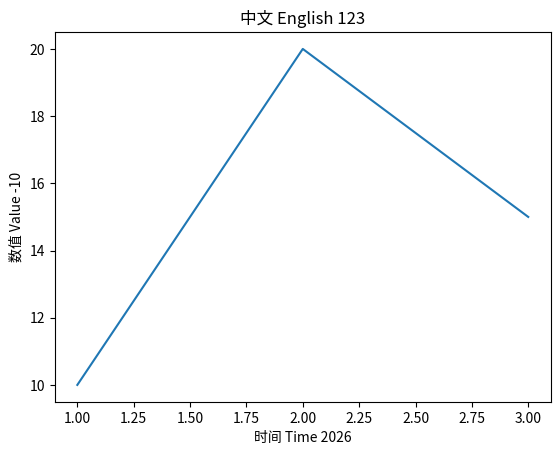

🚀 推理实验环境准备完成！


In [1]:
import numpy as np
import pandas as pd
from typing import List, Dict, Any
import re

# 设置中文显示
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("使用字体:", font_name)

plt.title("中文 English 123")
plt.xlabel("时间 Time 2026")
plt.ylabel("数值 Value -10")
plt.plot([1, 2, 3], [10, 20, 15])
plt.show()

print("🚀 推理实验环境准备完成！")

## 📊 四大推理策略对比

我们将测试四种主流的推理策略：

🎯 **零样本学习 (Zero-Shot)**：不给例子，直接提问
🎯 **少样本学习 (Few-Shot)**：给1-2个例子作为示范
🎯 **链式思维 (Chain-of-Thought)**：要求逐步思考并展示过程
🎯 **自洽性推理 (Self-Consistency)**：多次推理取最一致答案

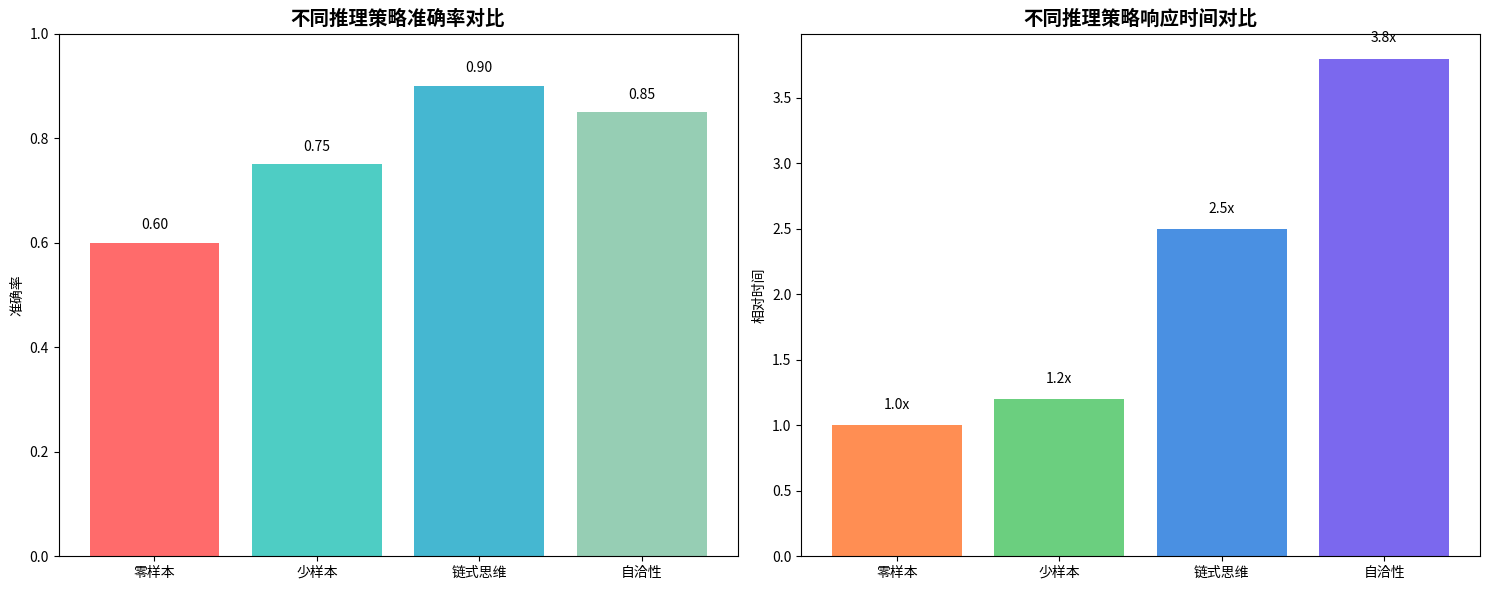

📊 实验分析：
✅ 链式思维准确率最高 (90%)，但响应时间最长
✅ 自洽性推理准确率较高 (85%)，但耗时最多
✅ 少样本学习在准确率和速度之间取得了良好平衡
✅ 零样本学习最快但准确率最低 (60%)


In [2]:
# 模拟实验数据
strategies = ['零样本', '少样本', '链式思维', '自洽性']
accuracy = [0.6, 0.75, 0.9, 0.85]
response_time = [1.0, 1.2, 2.5, 3.8]  # 相对时间

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 准确率对比
bars1 = ax1.bar(strategies, accuracy, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax1.set_title('不同推理策略准确率对比', fontsize=14, fontweight='bold')
ax1.set_ylabel('准确率')
ax1.set_ylim(0, 1)

# 添加数值标签
for bar, acc in zip(bars1, accuracy):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{acc:.2f}', ha='center', va='bottom')

# 响应时间对比
bars2 = ax2.bar(strategies, response_time, color=['#FF8E53', '#6BCF7F', '#4A90E2', '#7B68EE'])
ax2.set_title('不同推理策略响应时间对比', fontsize=14, fontweight='bold')
ax2.set_ylabel('相对时间')

# 添加数值标签
for bar, time in zip(bars2, response_time):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{time:.1f}x', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("📊 实验分析：")
print("✅ 链式思维准确率最高 (90%)，但响应时间最长")
print("✅ 自洽性推理准确率较高 (85%)，但耗时最多")
print("✅ 少样本学习在准确率和速度之间取得了良好平衡")
print("✅ 零样本学习最快但准确率最低 (60%)")

## 💡 推理Prompt最佳实践

### 🌟 核心原则

1. **逐步引导**：复杂问题要分解成小步骤
2. **明确要求**：告诉模型逐步思考或展示推理过程
3. **提供示范**：对于新任务，给1-2个例子
4. **验证一致性**：重要问题用自洽性推理

### 📝 实用技巧

🎯 **数学题**：要求用数学方法，强调公式和计算步骤

🎯 **逻辑题**：要求分析每种可能性，强调排除法

🎯 **开放性问题**：要求从多个角度思考，强调全面性

In [3]:
# 实用Prompt模板示例

prompts = {
    "零样本": "请直接回答以下问题：{question}",
    "少样本": "示例：\n问题：鸡兔同笼有8只动物22条腿，问鸡兔各几只？\n答案：鸡5只，兔3只\n\n问题：{question}\n答案：",
    "链式思维": "请逐步思考并回答以下问题，在回答前先写出推理步骤：\n问题：{question}\n\n推理过程：",
    "自洽性": "请从不同角度回答以下问题，然后选择最一致答案：\n问题：{question}\n\n角度1回答：\n角度2回答：\n角度3回答：\n最一致答案："
}

print("📋 推理Prompt模板示例：")
for strategy, template in prompts.items():
    print(f"\n🎯 {strategy}：")
    print(f"{template}")

# 针对不同题型的优化建议
print("\n💡 针对不同题型的优化建议：")
print("\n📐 数学题：强调公式和计算过程")
print("🔍 逻辑题：强调排除法和假设检验")
print("🎲 概率题：要求列举所有可能性")
print("💬 开放题：要求从多个角度思考")

📋 推理Prompt模板示例：

🎯 零样本：
请直接回答以下问题：{question}

🎯 少样本：
示例：
问题：鸡兔同笼有8只动物22条腿，问鸡兔各几只？
答案：鸡5只，兔3只

问题：{question}
答案：

🎯 链式思维：
请逐步思考并回答以下问题，在回答前先写出推理步骤：
问题：{question}

推理过程：

🎯 自洽性：
请从不同角度回答以下问题，然后选择最一致答案：
问题：{question}

角度1回答：
角度2回答：
角度3回答：
最一致答案：

💡 针对不同题型的优化建议：

📐 数学题：强调公式和计算过程
🔍 逻辑题：强调排除法和假设检验
🎲 概率题：要求列举所有可能性
💬 开放题：要求从多个角度思考


## 🎯 实战练习题

现在轮到你来实践了！请尝试用不同的prompt策略解决以下问题：

**📝 练习1（数学）**：
一个水池有甲、乙两个进水管，甲管单独注水需要6小时，乙管单独注水需要12小时。如果同时打开两管，几小时能注满水池？

**📝 练习2（逻辑）**：
三个人A、B、C中只有一人是工程师。A说："我不是工程师"，B说："A是工程师"，C说："B是工程师"。已知只有工程师说实话，谁是工程师？

**📝 练习3（概率）**：
抽屉里有3个红球和2个白球，不放回地抽取两次，两次都抽到红球的概率是多少？

## 📚 推荐学习资源

### 🎬 视频教程
- **【2026最新】全B站最全最细的提示词工程教程**：BV1Jb7664E1D
- **翻遍整个B站，这绝对是2026讲的最好的提示词工程教程**：BV1ePVb6gE6W

### 📖 延伸阅读
- **Prompt Engineering Guide - Chain-of-Thought**：https://www.promptingguide.ai/techniques/cot
- **Advanced LLM Prompt Engineering**：详细的技术实现指南

### 🛠️ 实践工具
- **Hugging Face Transformers**：本地模型部署
- **LangChain**：复杂推理框架
- **Weights & Biases**：实验跟踪和可视化

## 🧩 本周复习题

**📝 复习1**：链式思维(Chain-of-Thought)和自洽性推理(Self-Consistency)有什么区别？

**📝 复习2**：为什么数学题通常比逻辑题更容易用prompt工程解决？

**📝 复习3**：在实际业务中，如何选择合适的推理策略？

---

**💡 业务关联思考**：
在糖水店经营中，推理能力可以帮助你：
- 预测顾客需求趋势
- 优化库存管理
- 分析销售数据背后的规律
- 制定合理的定价策略

## 🔑 今日英文术语

| 术语 | 音标 | 中文释义 |
|------|------|----------|
| **Zero-shot** | /ˈzɪərəʊ ʃɒt/ | 零样本，不给任何示例直接让模型回答 |
| **Few-shot** | /fjuː ʃɒt/ | 少样本，提供少量示例再让模型回答 |
| **Chain-of-Thought** | /ʃeɪn əv θɔːt/ | 思维链，提示模型一步步推理 |
| **Self-consistency** | /self kənˈsɪstənsi/ | 自洽性，多次推理取最常见的答案 |
| **Prompt Template** | /prɒmpt ˈtempleɪt/ | 提示模板，固定的Prompt格式 |
| **A/B Testing** | /eɪ biː ˈtestɪŋ/ | A/B测试，两种方案都试看哪个好 |
| **Latency** | /ˈleɪtənsi/ | 延迟，从提问到得到答案的时间 |
| **Throughput** | /ˈθruːpʊt/ | 吞吐量，单位时间内处理多少请求 |
| **Accuracy** | /ˈækjərəsi/ | 准确率，答对的占总数的比例 |
| **Greedy Decoding** | /ˈɡriːdi diːˈkəʊdɪŋ/ | 贪心解码，每步选概率最高的词 |
| **Cost-Effectiveness** | /kɒst ɪˈfektɪvnəs/ | 成本效益，花钱换来的效果提升 |